In [ ]:
import os
import pandas as pd
import numpy as np
import pickle
import re
import math
import glob
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import joblib
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import spearmanr

from model import SV_CNN

SEED = 42

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

window_size = 400
window_abbr = "0.4"
print(f"window_size: {window_size}")
half_window_size = window_size // 2
subset_str = 'combined_t'

species = "Homo_sapiens"
species_space = species.replace("_", " ")

accession_to_chr = {
    'NC_000001.11': 'chr1', 
    'NC_000002.12': 'chr2', 
    'NC_000003.12': 'chr3', 
    'NC_000004.12': 'chr4', 
    'NC_000005.10': 'chr5', 
    'NC_000006.12': 'chr6', 
    'NC_000007.14': 'chr7', 
    'NC_000008.11': 'chr8', 
    'NC_000009.12': 'chr9', 
    'NC_000010.11': 'chr10', 
    'NC_000011.10': 'chr11', 
    'NC_000012.12': 'chr12', 
    'NC_000013.11': 'chr13', 
    'NC_000014.9': 'chr14', 
    'NC_000015.10': 'chr15', 
    'NC_000016.10': 'chr16', 
    'NC_000017.11': 'chr17', 
    'NC_000018.10': 'chr18', 
    'NC_000019.10': 'chr19', 
    'NC_000020.11': 'chr20', 
    'NC_000021.9': 'chr21', 
    'NC_000022.11': 'chr22', 
    'NC_000023.11': 'chrX', 
    'NC_000024.10': 'chrY'
}


n = 2
num_layers = f"{n}"
print(f"n: {num_layers}")

model = SV_CNN(4, 1)
if torch.cuda.is_available():
    model.to(device)
print(device)
print(model)

In [ ]:
data = pd.read_csv(f"{species}/{species}_balanced_data_{window_abbr}kb_annotated_{subset_str}.csv")
print(f"data.shape: {data.shape}")
print(data['chrom'].value_counts())
print(data.head())

feature_cols = ['chrom', 'sequence', 'label', 'sv_type', 'sv_len', 'pos', 'end',
       'left_start', 'left_end', 'right_start', 'right_end', 'num_del',
       'num_ins', 'num_inv', 'num_smalldel', 'num_smallins', 'gc_content',
       'full_snp_count', 'distance_to_exon', 'distance_to_Alu/SINE',
       'distance_to_L1/LINE', 'distance_to_L2/LINE', 
       'distance_to_Low_complexity/Low_complexity', 'distance_to_MIR/SINE', 'distance_to_Satellite/Satellite',
       'distance_to_Simple_repeat/Simple_repeat',
       'avg_phyloP_scores', 'avg_recomb_rate_full', 'avg_cCRE_full',
       'avg_DNase_score_full', 'avg_tf_score_full']

balanced_data = data[feature_cols].copy()
balanced_data['num_ins_del'] = balanced_data['num_ins'] + balanced_data['num_del']
balanced_data['num_small_indel'] = balanced_data['num_smallins'] + balanced_data['num_smalldel']
balanced_data.drop(['num_ins', 'num_del', 'num_smallins', 'num_smalldel', 'left_end', 'right_start'], inplace=True, axis=1)

balanced_data.rename({
    'num_small_indel': 'Number of small indels',
    'num_ins_del': 'Number of large insertions and deletions',
    'num_inv': 'Number of inversions',
    'gc_content': 'GC content',
    'distance_to_Alu/SINE': 'Distance to nearest Alu/SINE',
    'distance_to_L1/LINE': 'Distance to nearest L1/LINE',
    'distance_to_L2/LINE': 'Distance to nearest L2/LINE',
    'distance_to_MIR/SINE': 'Distance to nearest MIR/SINE',
    'distance_to_Simple_repeat/Simple_repeat': 'Distance to nearest simple repeat',
    'distance_to_exon': 'Distance to nearest exon',
    'distance_to_Satellite/Satellite': 'Distance to nearest satellite',
    'distance_to_Low_complexity/Low_complexity': 'Distance to nearest low complexity repeat',
    'avg_phyloP_scores': 'Average phyloP score',
    'full_snp_count': 'Number of SNPs',
    'avg_DNase_score_full': 'Average DNase accessibility score',
    'avg_cCRE_full': 'Average cCRE score',
    'avg_tf_score_full': 'Average transcription factor peak',
    'avg_recomb_rate_full': 'Average recombination rate'
}, axis=1, inplace=True)

print(len(balanced_data['sequence'].iloc[0]))

mapping = {'A': [1, 0, 0, 0], 'T': [0, 1, 0, 0], 'C': [0, 0, 1, 0], 'G': [0, 0, 0, 1], 'N': [0, 0, 0, 0]}

def one_hot_encode(seq, mapping):
    return np.array([mapping[ch] for ch in seq])

def get_middle(seq):
    center = len(seq) // 2
    start = max(center - 500, 0)
    end = start + 1000
    return seq[start:end]

X_categorical = np.array([one_hot_encode(seq, mapping) for seq in balanced_data['sequence']])
y = balanced_data['label'].values
indices = np.arange(len(y))

num_feature_cols = ['Number of large insertions and deletions',
       'Number of small indels', 'Number of inversions', 'GC content',
       'Number of SNPs', 'Distance to nearest exon', 'Distance to nearest Alu/SINE',
       'Distance to nearest L1/LINE', 'Distance to nearest L2/LINE', 
       'Distance to nearest low complexity repeat', 'Distance to nearest MIR/SINE', 'Distance to nearest satellite',
       'Distance to nearest simple repeat',
       'Average phyloP score', 'Average recombination rate', 'Average cCRE score',
       'Average DNase accessibility score', 'Average transcription factor peak']

X_numerical = balanced_data[num_feature_cols].astype(float).to_numpy()
print(X_categorical.shape, X_numerical.shape, y.shape)

X_train_val, X_test, y_train_val, y_test, X_num_train_val, X_num_test, train_val_idx, test_idx = train_test_split(
    X_categorical, y, X_numerical, indices, test_size=0.20, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val, X_num_train, X_num_val, train_idx, val_idx = train_test_split(
    X_train_val, y_train_val, X_num_train_val, train_val_idx, test_size=0.25, random_state=SEED, stratify=y_train_val
)

scaler = StandardScaler()
scaler.fit(X_num_train)
joblib.dump(scaler, f"{species}/{species}_{window_abbr}kb_scaler.pkl")

X_num_train_scaled = scaler.transform(X_num_train)
X_num_val_scaled = scaler.transform(X_num_val)
X_num_test_scaled = scaler.transform(X_num_test)

X_cat_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
X_cat_val_tensor = torch.tensor(X_val, dtype=torch.float32).permute(0, 2, 1)
X_cat_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 2, 1)

X_num_train_tensor = torch.tensor(X_num_train_scaled, dtype=torch.float32)
X_num_val_tensor = torch.tensor(X_num_val_scaled, dtype=torch.float32)
X_num_test_tensor = torch.tensor(X_num_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_data = TensorDataset(X_cat_train_tensor, X_num_train_tensor, y_train_tensor)
val_data = TensorDataset(X_cat_val_tensor, X_num_val_tensor, y_val_tensor)
test_data = TensorDataset(X_cat_test_tensor, X_num_test_tensor, y_test_tensor)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_data, batch_size=128)

print("X_cat_train_tensor.shape, X_num_train_tensor.shape, y_train_tensor.shape")
print(X_cat_train_tensor.shape, X_num_train_tensor.shape, y_train_tensor.shape)

### Model predictions vs allele frequency on test set

In [ ]:
vcf_df_af = pd.read_csv("../Homo_sapiens/vcf_parsed_with_af.csv")
test_df = pd.read_csv(f"{species}/Homo_sapiens_0.4kb_test_df_combined_t.csv")
test_df

,Number of large insertions and deletions,Number of small indels,Number of inversions,GC content,Number of SNPs,Distance to nearest exon,Distance to nearest Alu/SINE,Distance to nearest L1/LINE,Distance to nearest L2/LINE,Distance to nearest low complexity repeat,...,Distance to nearest satellite,Distance to nearest simple repeat,Average phyloP score,Average recombination rate,Average cCRE score,Average DNase accessibility score,Average transcription factor peak,CNN predicted probability,Ensemble probability,True label
0,0.0,1.0,0.0,31.50,0.0,200.0,200.0,0.0,200.0,200.0,...,200.0,200.0,0.087985,0.000000e+00,0.000000,0.0,0.000000,0.062743,0.093,0
1,11.0,9.0,0.0,65.50,22.0,200.0,200.0,200.0,200.0,200.0,...,200.0,200.0,-0.067168,2.156970e+00,0.000000,0.0,0.000000,0.997952,0.998,1
2,0.0,4.0,0.0,40.75,2.0,200.0,0.0,0.0,200.0,200.0,...,200.0,200.0,0.008898,9.362320e-21,0.000000,0.0,0.000000,0.135620,0.553,0
3,4.0,5.0,4.0,69.00,15.0,200.0,200.0,200.0,200.0,200.0,...,200.0,200.0,-0.338517,8.767470e-05,2.899468,112.0,73.387061,0.998221,0.917,1
4,0.0,1.0,0.0,29.00,3.0,200.0,200.0,200.0,200.0,200.0,...,200.0,200.0,0.143323,1.751170e-24,0.000000,0.0,0.000000,0.177206,0.095,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69525,0.0,3.0,0.0,34.50,5.0,200.0,0.0,200.0,200.0,200.0,...,200.0,7.0,0.051777,2.030440e-02,0.000000,0.0,0.000000,0.193127,0.573,0
69526,0.0,0.0,0.0,30.50,2.0,200.0,200.0,200.0,200.0,200.0,...,200.0,200.0,0.236925,0.000000e+00,0.000000,0.0,0.000000,0.511311,0.209,0
69527,0.0,3.0,0.0,51.75,3.0,200.0,0.0,143.0,200.0,200.0,...,200.0,200.0,0.031232,9.935810e-04,0.000000,0.0,0.000000,0.489475,0.320,0
69528,0.0,0.0,0.0,36.75,7.0,200.0,200.0,0.0,200.0,200.0,...,200.0,200.0,0.097390,1.905080e-04,0.000000,0.0,0.000000,0.053128,0.146,0


In [ ]:
balanced_data["id"] = (
    balanced_data["chrom"].astype(str)
    + "-" +
    (balanced_data["pos"] + 2).astype(int).astype(str)
    + "-" +
    balanced_data["sv_type"].astype(str)
    + "-" +
    balanced_data["sv_len"].astype(str)
)

balanced_data = balanced_data.merge(
    vcf_df_af[["ID", "ALLELE_FREQUENCY"]],
    how="left",
    left_on="id",
    right_on="ID"
).drop(columns=["ID"])

af_data = balanced_data.copy(deep=True)
matched = (af_data["ALLELE_FREQUENCY"] > 0).sum()
total = len(af_data)
print(f"Matched {matched} / {total} rows ({matched/total:.2%})")


_, _, _, _, _, _, _, test_idx = train_test_split(
    X_categorical, y, X_numerical, indices,
    test_size=0.20, random_state=SEED, stratify=y
)
print(len(test_idx), len(test_idx) /  len(af_data))

af_data["row_id"] = np.arange(len(af_data))

indices = af_data["row_id"].values
test_rows = af_data.loc[test_idx].copy()

test_df = test_df.copy()
test_df["row_id"] = test_idx

test_rows = test_rows.merge(
    test_df[["row_id", "CNN predicted probability", "Ensemble probability"]],
    on="row_id",
    how="left"
)

# Keep only SVs (label == 1)
test_rows = test_rows[test_rows['label'] == 1]
print(test_rows.shape)

test_rows = test_rows.dropna(subset=["ALLELE_FREQUENCY"])
print(test_rows.shape)

test_rows = test_rows.rename(columns={
    "CNN predicted probability": "CNN probability",
    "Ensemble probability": "Ensemble probability"
})

# AF binning
bins = [0, 0.01, 0.02, 1]
bin_labels = [
    "Singletons (0–1%)",
    "Low frequency (1–2%)",
    "Intermediate (>2%)"
]

test_rows["AF_bin"] = pd.cut(
    test_rows["ALLELE_FREQUENCY"],
    bins=bins,
    labels=bin_labels,
    include_lowest=True
)

print("\nAF bin counts:")
print(test_rows["AF_bin"].value_counts(dropna=False))

test_rows.to_csv(f"{species}/test_df_annotations_predictions.csv", index=False)

/tmp/ipykernel_3097241/3767393106.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = valid.groupby("AF_bin")[prob_col].mean().reindex(bin_categories)


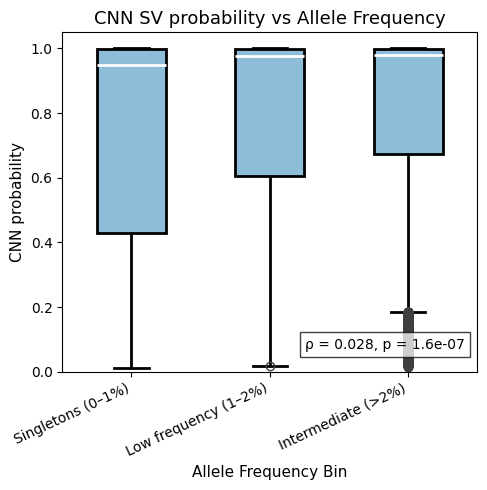

/tmp/ipykernel_3097241/3767393106.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = valid.groupby("AF_bin")[prob_col].mean().reindex(bin_categories)


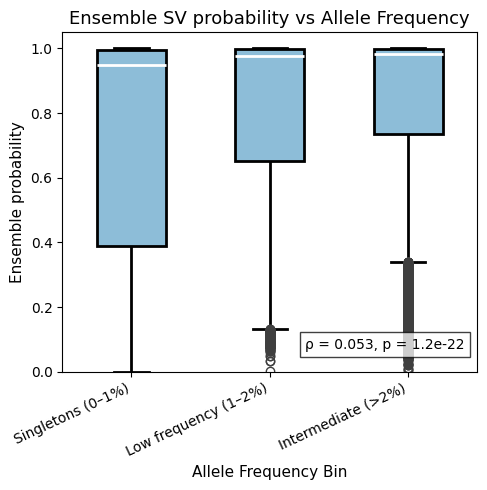

In [ ]:
def plot_af_box(df, prob_col, title, outname):

    plt.figure(figsize=(5, 5))

    # Spearman correlation
    rho_cont, p_cont = spearmanr(df["ALLELE_FREQUENCY"], df[prob_col], nan_policy="omit")

    valid = df.dropna(subset=["AF_bin"]).copy()
    bin_categories = valid["AF_bin"].cat.categories if hasattr(valid["AF_bin"], "cat") else sorted(valid["AF_bin"].unique())
    bin_map = {b: i for i, b in enumerate(bin_categories)}
    bin_means = valid.groupby("AF_bin")[prob_col].mean().reindex(bin_categories)

    x_bin = np.array([bin_map[b] for b in bin_categories])
    y_bin = bin_means.values

    rho_bin, p_bin = spearmanr(x_bin, y_bin, nan_policy="omit")

    sns.boxplot(
        data=df, x="AF_bin", y=prob_col,
        whis=1.5, showfliers=True,
        width=0.5,
        boxprops=dict(facecolor="#8DBDD8", edgecolor="black", linewidth=2),
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color="black", linewidth=2),
        capprops=dict(color="black", linewidth=2)
    )

    txt = (
        f"ρ = {rho_cont:.3f}, p = {p_cont:.2g}"
        )

    plt.text(
        0.97, 0.10,
        txt,
        transform=plt.gca().transAxes,
        ha="right", va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="black")
    )

    plt.xlabel("Allele Frequency Bin", fontsize=11)
    plt.ylabel(prob_col, fontsize=11)
    plt.title(title, fontsize=13)
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(outname, dpi=300, bbox_inches="tight")
    plt.show()


out_prefix = f"{species}/{species}_{window_abbr}kb_{subset_str}"

plot_af_box(
    test_rows,
    "CNN probability",
    "CNN SV probability vs Allele Frequency",
    f"{out_prefix}_AF_boxplot_cnn.pdf"
)

plot_af_box(
    test_rows,
    "Ensemble probability",
    "Ensemble SV probability vs Allele Frequency",
    f"{out_prefix}_AF_boxplot_ensemble.pdf"
)

### CADD-SV vs model predictions

In [ ]:
max_per_file = 9000
set_name = "test"
output_dir = "CADD-SV/input_test"
os.makedirs(output_dir, exist_ok=True)

chrom_order = [
    *(f"chr{i}" for i in range(1, 23)),
    "chrX", "chrY", "chrM"
]

test_rows = pd.read_csv(f"{species}/test_df_annotations_predictions.csv")
bed_df = test_rows[["chrom", "pos", "end", "sv_type"]].copy()
bed_df["pos"] = bed_df["pos"].astype(int)
bed_df["end"] = bed_df["end"].astype(int)

bed_df["chrom"] = bed_df["chrom"].astype(pd.api.types.CategoricalDtype(categories=chrom_order, ordered=True))

n = len(bed_df)
num_files = math.ceil(n / max_per_file)

for i in range(num_files):
    start_i = i * max_per_file
    end_i = min((i + 1) * max_per_file, n)
    chunk = bed_df.iloc[start_i:end_i]

    chunk = chunk.sort_values(["chrom", "pos", "end"])

    out_path = f"{output_dir}/id_{set_name}_{i+1}.bed"
    chunk.to_csv(out_path, sep="\t", header=False, index=False)

    print(f"Saved {len(chunk)} SVs → {out_path}")

print(f"\nTotal SVs written: {n}")
print(f"Total BED files generated: {num_files}")


In [ ]:
input = pd.read_csv(f"{species}/{species}_gene_positions_constraint_{window_abbr}kb_cadd.csv")
input = input.dropna(how='any')

files = glob.glob("CADD-SV/v1.1_*.tsv")

processed_dfs = []
for f in files:
    cadd = pd.read_csv(f, sep="\t")

    cadd = cadd.reset_index()
    cadd.columns = cadd.iloc[0]
    cadd = cadd[1:] 
    cadd = cadd.reset_index(drop=True)
    cadd = cadd.rename({'#Chrom': 'Chrom'}, axis=1)

    processed_dfs.append(cadd)

df = pd.concat(processed_dfs, ignore_index=True)

print("\nLoaded files:", files)
print("Combined shape:", df.shape)
df["Chrom"] = df["Chrom"].astype(str).apply(lambda x: "chr" + x)
df.to_csv("CADD-SV/CADDSV_test_set_combined.csv", index=False)
df

In [ ]:
test_rows["pos"] = test_rows["pos"].astype(int)
test_rows["end"] = test_rows["end"].astype(int)
df["Start"] = df["Start"].astype(int)
df["End"] = df["End"].astype(int)

merged = test_rows.merge(
    df,
    left_on=["chrom", "pos", "end", "sv_type"],
    right_on=["Chrom", "Start", "End", "Type"],
    how="inner"
)
merged

In [ ]:
x_vars = ["CNN probability", "Ensemble probability"]
y_vars = ["CADD-SV_PHRED-score", "CADD-SV_Raw-score"]

for c in x_vars + y_vars:
    merged[c] = pd.to_numeric(merged[c], errors="coerce")

os.makedirs(species, exist_ok=True)

for y in y_vars:
    for x in x_vars:
        fig = plt.figure(figsize=(6, 6))
        gs = GridSpec(4, 4, figure=fig)

        ax_scatter = fig.add_subplot(gs[1:4, 0:3])
        ax_xkde = fig.add_subplot(gs[0, 0:3], sharex=ax_scatter)
        ax_ykde = fig.add_subplot(gs[1:4, 3], sharey=ax_scatter)

        xs = merged[x].dropna()
        ys = merged[y].dropna()

        ax_scatter.scatter(xs, ys, s=8, alpha=0.5, color='orange')

        mask = np.isfinite(xs) & np.isfinite(ys)
        bx, by = xs[mask], ys[mask]
        if len(bx) > 2:
            m, b = np.polyfit(bx, by, 1)
            x_line = np.linspace(bx.min(), bx.max(), 100)
            ax_scatter.plot(x_line, m * x_line + b, linestyle="dotted", color="red")

        try:
            kde_x = gaussian_kde(xs)
            x_eval = np.linspace(xs.min(), xs.max(), 200)
            ax_xkde.plot(x_eval, kde_x(x_eval), color="black", linewidth=1)
            ax_xkde.fill_between(x_eval, kde_x(x_eval), alpha=0.3, color='orange')
        except Exception:
            pass

        try:
            kde_y = gaussian_kde(ys)
            y_eval = np.linspace(ys.min(), ys.max(), 200)
            ax_ykde.plot(kde_y(y_eval), y_eval, color="black", linewidth=1)
            ax_ykde.fill_betweenx(y_eval, kde_y(y_eval), alpha=0.3, color='orange')
        except Exception:
            pass

        ax_xkde.set_yticks([])
        ax_ykde.set_xticks([])

        rho, p = spearmanr(xs, ys, nan_policy='omit')
        ax_scatter.text(
            0.05, 0.95,
            f"Spearman ρ = {rho:.3f}\np = {p:.1e}",
            transform=ax_scatter.transAxes,
            verticalalignment="top",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
        )

        ax_scatter.set_xlabel(x.replace("_", " "))
        ax_scatter.set_ylabel(y.replace("_", " "))

        clean_x = x.replace(" ", "_")
        clean_y = y.replace(" ", "_")
        outpath = f"{species}/{species}_{window_abbr}kb_{clean_x}_vs_{clean_y}.pdf"

        fig.tight_layout()
        fig.savefig(outpath.replace(".pdf", ".png"), format="png", dpi=500, bbox_inches="tight")

        plt.close(fig)

In [ ]:
merged["sv_len"] = pd.to_numeric(merged["sv_len"], errors="coerce")
merged["CADD-SV_PHRED-score"] = pd.to_numeric(merged["CADD-SV_PHRED-score"], errors="coerce")
merged["CADD-SV_Raw-score"] = pd.to_numeric(merged["CADD-SV_Raw-score"], errors="coerce")

def plot_linear(ycol, ylabel, outfile):
    xs = merged["sv_len"]
    ys = merged[ycol]

    fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(xs, ys, s=8, alpha=0.15, color='seagreen')
    rho, p = spearmanr(xs, ys, nan_policy="omit")

    mask = np.isfinite(xs) & np.isfinite(ys)
    if mask.sum() > 2:
        m, b = np.polyfit(xs[mask], ys[mask], 1)
        x_line = np.linspace(xs.min(), xs.max(), 200)
        ax.plot(x_line, m * x_line + b, linestyle="dotted", color="red")

    ax.text(
        0.05, 0.95,
        f"Spearman ρ = {rho:.3f}\np = {p:.1e}",
        transform=ax.transAxes,
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
    )

    ax.set_xlabel("SV length (bp)")
    ax.set_ylabel(ylabel)
    ax.set_xscale("log")

    plt.tight_layout()
    fig.savefig(outfile.replace(".pdf", ".png"), format="png", dpi=500, bbox_inches="tight")
    plt.show()

plot_linear(
    "CADD-SV_PHRED-score",
    "CADD-SV PHRED score",
    "Homo_sapiens/caddsv_phred_vs_svlen.pdf"
)

plot_linear(
    "CADD-SV_Raw-score",
    "CADD-SV Raw score",
    "Homo_sapiens/caddsv_raw_vs_svlen.pdf"
)


### Gene functional constraints vs model predictions

In [ ]:
constraints = pd.read_csv(f"{species}/gnomad.v4.1.constraint_metrics.tsv", sep='\t')

gff_cols = [
    "SEQ_ID", "SOURCE", "FEATURE", "START", "END",
    "SCORE", "STRAND", "PHASE", "ATTRIBUTES"
]

gff = pd.read_csv(f"../hg38p14/ncbi_dataset/data/GCF_000001405.40/genomic.gff", sep="\t", comment="#", names=gff_cols)
gene_gff = gff[gff["FEATURE"] == "gene"].copy()

def extract_geneid(attr):
    m = re.search(r"GeneID:(\d+)", attr)
    return int(m.group(1)) if m else None

gene_gff["GeneID"] = gene_gff["ATTRIBUTES"].apply(extract_geneid)
gene_gff = gene_gff.dropna(subset=["GeneID"])
gene_gff["GeneID"] = gene_gff["GeneID"].astype(int)

merged = gene_gff.merge(
    constraints,
    left_on="gene_symbol",
    right_on="gene",
    how="left"
)
merged.iloc[:5, 8:14]

In [ ]:
merged_clean = merged.dropna(subset=["gene"]).copy()
keep_cols = ["SEQ_ID", "SOURCE", "FEATURE", "START", "END",
    "gene", 
    "gene_id",
    "lof.oe_ci.upper",
    "lof_hc_lc.pLI",
    "lof.pLI",
    "lof.z_score",
    "mis.z_score",
    "syn.z_score"
]

keep_cols = [c for c in keep_cols if c in merged_clean.columns]
merged_clean = merged_clean[keep_cols].copy()

print("Final columns:", merged_clean.columns.tolist())
print("Final shape:", merged_clean.shape)

merged_clean.to_csv(f"{species}/PLI_genes.csv", index=False)

In [ ]:
gene_constraint = pd.read_csv(f"{species}/PLI_genes.csv")
valid_accessions = set(accession_to_chr.keys())

gene_constraint_filtered = gene_constraint[
    gene_constraint["SEQ_ID"].isin(valid_accessions)
].copy()

gene_constraint_filtered["chrom"] = gene_constraint_filtered["SEQ_ID"].map(accession_to_chr)
gene_constraint_filtered['START'] = gene_constraint_filtered['START'] - 1
gene_constraint_filtered['END'] = gene_constraint_filtered['END'] - 1

gene_constraint_filtered = gene_constraint_filtered.dropna(subset=["lof.oe_ci.upper"]).copy()

gene_constraint_filtered = gene_constraint_filtered[gene_constraint_filtered["FEATURE"] == "gene"].copy()
gene_gff_unique = gene_constraint_filtered.drop_duplicates(subset="gene", keep="first").copy()
gene_gff_unique.to_csv(f"{species}/PLI_genes_cleaned.csv", index=False)

In [ ]:
subset_str = "constraint"
df = pd.read_csv(f"{species}/{species}_gene_positions_constraint_{window_abbr}kb_{subset_str}.csv")
pli = pd.read_csv(f"{species}/PLI_genes_cleaned.csv")
predictions = pd.read_csv(f"{species}/{species}_0.4_gene_positions_constraint_predictions_constraint.csv")

In [ ]:
# Aggregate model probabilities per gene
gene_means = (
    predictions.groupby("gene", as_index=False)
    .agg({
        "RF_prob_without_CNN": "mean",
        "CNN_prob": "mean",
        "Ensemble_prob": "mean"
    })
)

constraint_cols = [
    "gene",
    "SEQ_ID", 
    "START",
    "END", 
    "lof.oe_ci.upper",
    "lof_hc_lc.pLI",
    "lof.pLI",
    "lof.z_score",
    "mis.z_score",
    "syn.z_score"
]

pli_sub = pli[constraint_cols]
merged_gene_summary = gene_means.merge(pli_sub, on="gene", how="left")

with open(f"{species}/big_trees.pkl", "rb") as f:
    big_trees = pickle.load(f)

In [ ]:
df = merged_gene_summary.copy()

df["CHROM"] = df["SEQ_ID"].map(accession_to_chr)

# Compute 200 bp upstream/downstream windows
df["window_start"] = df["START"] - 200
df["window_end"]   = df["END"] + 200
df["window_start"] = df["window_start"].clip(lower=1)

# Count SVs in each region
def count_svs(chrom, start, end):
    total = 0
    for (c, svt), tree in big_trees.items():
        if c != chrom:
            continue
        total += len(tree.overlap(start, end))
    return total

df["SV_count"] = df.apply(
    lambda r: count_svs(r["CHROM"], r["window_start"], r["window_end"]),
    axis=1
)

print(df[["gene", "CHROM", "window_start", "window_end", "SV_count"]].head())
df.to_csv(f"{species}/genes_prob_constraint_count.csv", index=False)

In [ ]:
white_red = LinearSegmentedColormap.from_list(
    "white_red",
    [
        (0.0, "#FFF9F9"),
        (0.4, "#F7B6B6"),
        (0.7, "#E84A5F"),
        (1.0, "#B30000"),
    ]
)

def jitter_for_log_scale(x, jitter_strength=0.5):
    """
    Multiplicative jitter for log-scale axes.
    x: array-like integer counts
    jitter_strength: max fractional shift, e.g. 0.08 = ±8%
    """
    x = np.asarray(x, dtype=float)
    jitter_factor = 1 + np.random.uniform(-jitter_strength, jitter_strength, size=len(x))
    
    x_safe = np.where(x <= 0, 0.5, x)

    return x_safe * jitter_factor


def plot_2d(x, y, color, title, ylabel, name):

    # Spearman correlation
    rho, p = spearmanr(x, y)

    # jitter for log scale
    x_jitter = jitter_for_log_scale(x, jitter_strength=0.33)
    y_jitter = y  # no jitter on y

    plt.figure(figsize=(7, 6))

    sc = plt.scatter(
        x_jitter, y_jitter,
        c=color,
        cmap=white_red,
        s=20,
        alpha=0.7,
        linewidth=0.5
    )

    plt.xlabel("True number of SVs in ±200 bp region", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)

    plt.text(
        0.97, 0.95,
        f"ρ = {rho:.3f}\np = {p:.3g}",
        transform=plt.gca().transAxes,
        ha="right", va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="black")
    )

    cbar = plt.colorbar(sc)
    cbar.set_label("pLI value")
    plt.xscale("log")
    plt.tight_layout()

    plt.savefig(f"{species}/{species}_{name}_prob_count_pli.png", format="png",
            dpi=500, bbox_inches="tight")
    plt.show()


# Ensemble probability vs SV_count
plot_2d(
    x=df["SV_count"],
    y=df["Ensemble_prob"],
    color=df["lof.pLI"],
    title="Ensemble Probability vs SV Count (colored by pLI)",
    ylabel="Ensemble probability",
    name="ensemble"
)

# CNN probability vs SV_count
plot_2d(
    x=df["SV_count"],
    y=df["CNN_prob"],
    color=df["lof.pLI"],
    title="CNN Probability vs SV Count (colored by pLI)",
    ylabel="CNN probability",
    name="cnn"
)


In [ ]:
df = merged_gene_summary.copy()

plots = [
    ("CNN_prob", "lof.oe_ci.upper", "CNN probability vs LOEUF"),
    ("Ensemble_prob", "lof.oe_ci.upper", "Ensemble probability vs LOEUF"),
    ("CNN_prob", "lof.pLI", "CNN probability vs pLI"),
    ("Ensemble_prob", "lof.pLI", "Ensemble probability vs pLI")
]

name_map = {"lof.oe_ci.upper": "LOEUF", "lof.pLI": "PLI", "CNN_prob": "CNN probability", "Ensemble_prob": "Ensemble probability"}

for y, x, title in plots:

    sub = df[[x, y]].dropna()

    # numeric bins
    num_bins = 10
    edges = np.linspace(sub[x].min(), sub[x].max(), num_bins + 1)
    sub["bin"] = np.digitize(sub[x], edges, right=True)
    sub["bin"] = sub["bin"].clip(1, num_bins)
    bin_midpoints = [(edges[i] + edges[i+1]) / 2 for i in range(num_bins)]

    rho, p = spearmanr(sub[x], sub[y])

    plt.figure(figsize=(7,5))

    sns.boxplot(
        data=sub,
        x="bin",
        y=y,
        color="orange",
        boxprops={"edgecolor":"black", "linewidth":1.4},
        medianprops={"color":"white", "linewidth":2},
        whiskerprops={"color":"black"},
        capprops={"color":"black"},
    )

    plt.xlabel(f"{name_map[x]}")
    plt.ylabel(name_map[y])

    plt.xticks(
        ticks=range(num_bins),
        labels=[f"{m:.2f}" for m in bin_midpoints],
        rotation=25,
        ha="right"
    )

    plt.text(
        0.97, 0.89,
        f"ρ = {rho:.3f}\np = {p:.3g}",
        transform=plt.gca().transAxes,
        ha="right",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="black")
    )

    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"{species}/{species}_{name_map[x]}_{y}.pdf", dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
plots = [
    ("CNN_prob", "lof.pLI", "CNN probability vs pLI"),
    ("Ensemble_prob", "lof.pLI", "Ensemble probability vs pLI"),
]

name_map = {
    "lof.pLI": "pLI",
    "CNN_prob": "CNN probability",
    "Ensemble_prob": "Ensemble probability"
}

for y, x, title in plots:

    sub = df[[x, y, "gene"]].dropna()

    mask = (sub[x] > 0.9) & (sub[y] > 0.6)
    outliers = sub[mask]

    plt.figure(figsize=(7, 6))
    ax = plt.gca()

    plt.scatter(
        sub[x], sub[y],
        s=18, color="#66A1D2", alpha=0.4, edgecolor=None
    )

    plt.scatter(
        outliers[x], outliers[y],
        s=45, color="red", edgecolor="black", linewidth=1.0, zorder=3
    )

    texts = []
    for _, r in outliers.iterrows():
        texts.append(
            plt.text(
                r[x], r[y],
                r["gene"],
                fontsize=8,
                weight="bold",
                color="black"
            )
        )

    adjust_text(
        texts,
        only_move={'points': 'y', 'texts': 'xy'},
        arrowprops=dict(arrowstyle="-", color="black", lw=0.5)
    )

    plt.xlabel(name_map[x])
    plt.ylabel(name_map[y])
    plt.title(title)

    plt.tight_layout()
    plt.savefig(f"{species}/{species}_{name_map[x]}_{y}_scatter_outliers.png", format="png",
                dpi=500, bbox_inches="tight")
    plt.show()
